In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

In [ ]:
df = pd.read_excel("telco_customer.xlsx", header=None)
df = df[0].str.split(",", expand=True)
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)

#Check Data
print(df.head())
print(f"\nShape: {df.shape}")

0 customer_id plan_type device_brand avg_data_usage_gb      pct_video_usage  \
0      C00001   Prepaid       Realme               1.5   0.8041460263450491   
1      C00002  Postpaid         Vivo              1.09  0.10768637529365216   
2      C00003  Postpaid       Xiaomi              3.24  0.31389398380624134   
3      C00004   Prepaid        Apple              5.32  0.42015759810355613   
4      C00005   Prepaid       Huawei              1.91   0.2516379006484085   

0 avg_call_duration sms_freq monthly_spend topup_freq         travel_score  \
0              7.98       13       70000.0          4   0.2844189968419545   
1              9.56        9       63000.0          3  0.11508628205361705   
2              4.61       13       89000.0          7  0.40299759641160643   
3              6.96        8       67000.0          4   0.3021685393268597   
4             11.01       21       72000.0          5   0.4879106397322117   

0 complaint_count   target_offer  
0               0  Ge

In [ ]:
#check missing values
print(df.isna().sum())

0
customer_id          0
plan_type            0
device_brand         0
avg_data_usage_gb    0
pct_video_usage      0
avg_call_duration    0
sms_freq             0
monthly_spend        0
topup_freq           0
travel_score         0
complaint_count      0
target_offer         0
dtype: int64


In [ ]:
customer_ids = df["customer_id"]
df = df.drop(columns=["customer_id"])

In [ ]:
#convert ke numerik
numeric_cols = [
    "avg_data_usage_gb", "pct_video_usage", "avg_call_duration",
    "sms_freq", "monthly_spend", "topup_freq",
    "travel_score", "complaint_count"
]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

In [ ]:
#check negative values
print((df[numeric_cols] < 0).sum())

0
avg_data_usage_gb      0
pct_video_usage        0
avg_call_duration    229
sms_freq               0
monthly_spend          2
topup_freq             0
travel_score           0
complaint_count        0
dtype: int64


In [ ]:
#fix negative values di avg_call_duration dan monthly_spend
df["avg_call_duration"] = df["avg_call_duration"].abs()
df.loc[df["monthly_spend"] < 0, "monthly_spend"] = np.nan
df["monthly_spend"] = df["monthly_spend"].fillna(df["monthly_spend"].median())
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [ ]:
#check outlier
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col:25} | Range: [{df[col].min():8.2f}, {df[col].max():8.2f}] | Outliers: {outliers:4d}")

avg_data_usage_gb         | Range: [    0.03,    39.02] | Outliers:  305
pct_video_usage           | Range: [    0.00,     1.00] | Outliers:   40
avg_call_duration         | Range: [    0.01,    27.77] | Outliers:   34
sms_freq                  | Range: [    4.00,    31.00] | Outliers:   17
monthly_spend             | Range: [ 2000.00, 450000.00] | Outliers:  249
topup_freq                | Range: [    0.00,    12.00] | Outliers:  110
travel_score              | Range: [    0.00,     0.85] | Outliers:   70
complaint_count           | Range: [    0.00,     5.00] | Outliers:  138


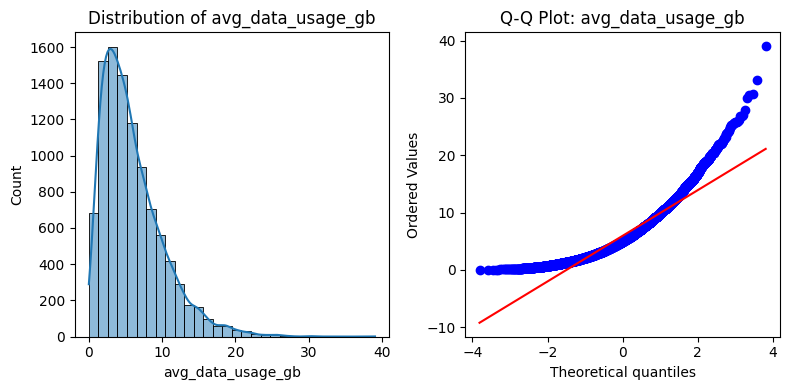

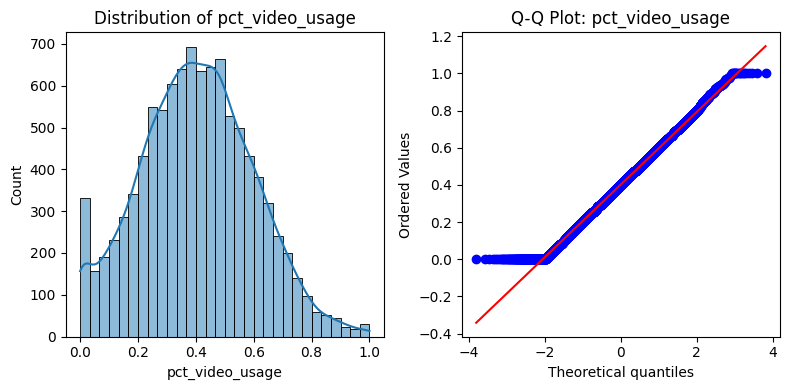

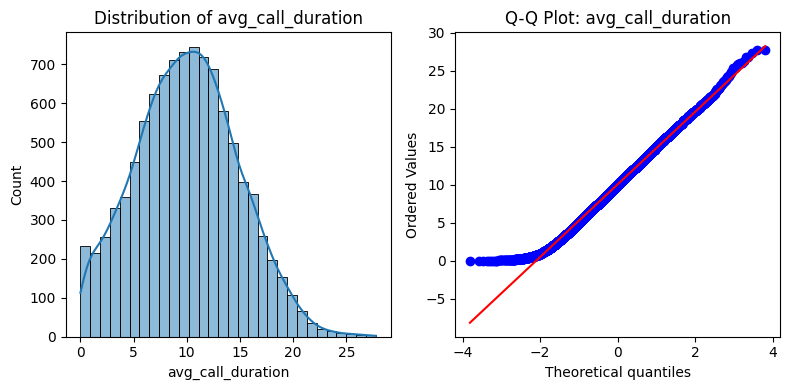

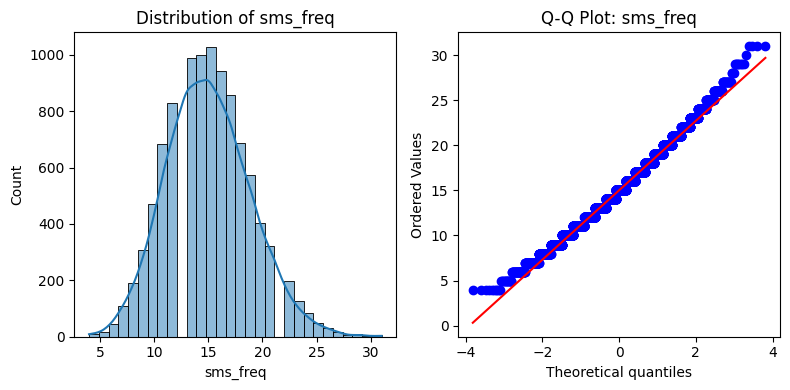

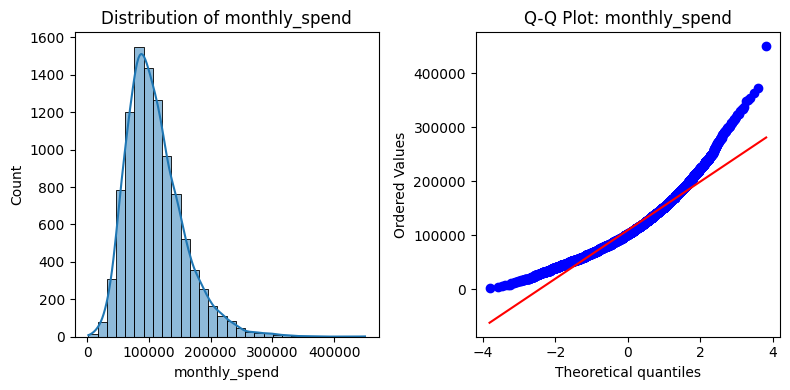

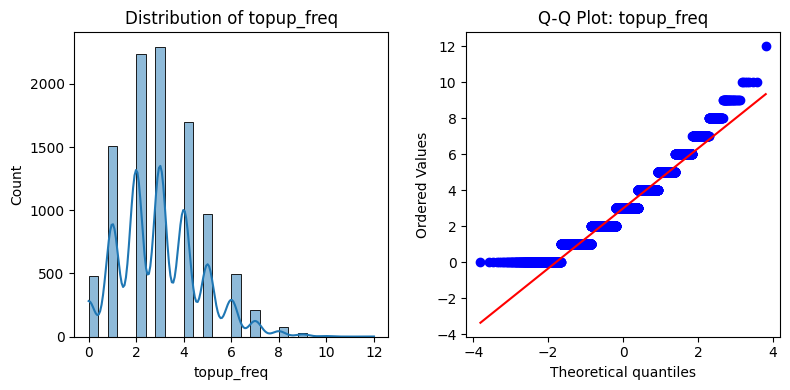

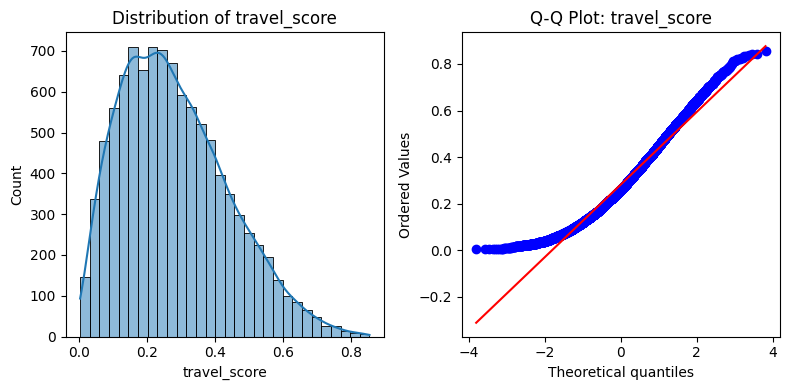

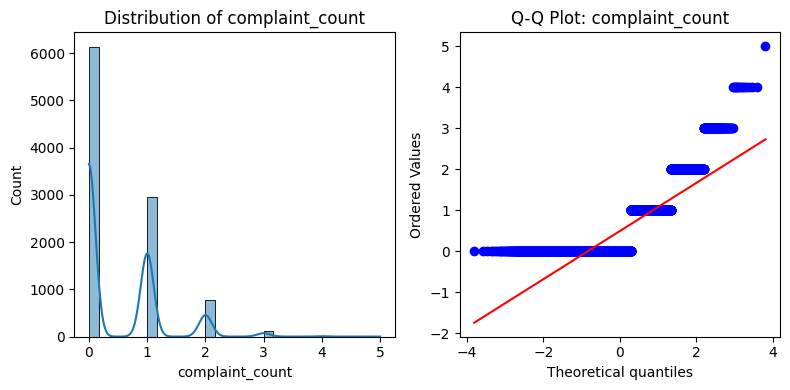

In [ ]:
#check distribusi data
for col in numeric_cols:
    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")

    plt.subplot(1, 2, 2)
    from scipy import stats
    stats.probplot(df[col].dropna(), dist="norm", plot=plt)
    plt.title(f"Q-Q Plot: {col}")

    plt.tight_layout()
    plt.show()

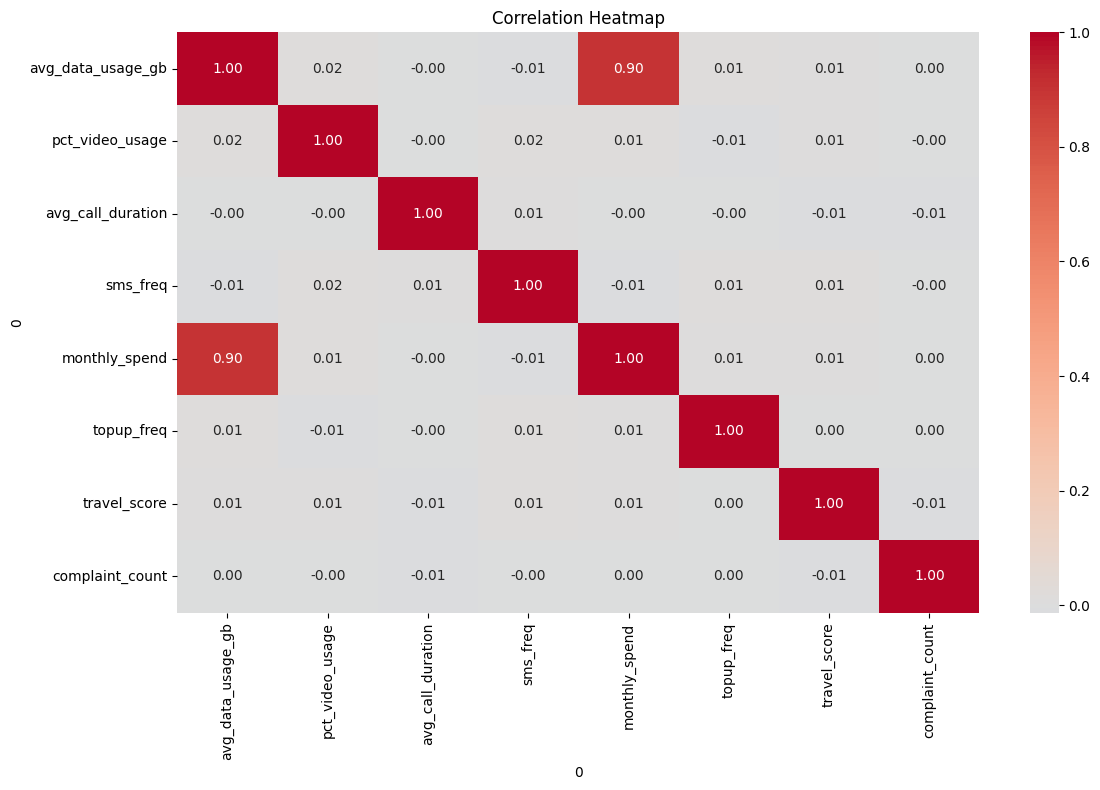

In [ ]:
#correlation matrix
plt.figure(figsize=(12, 8))
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
y = LabelEncoder().fit_transform(df["target_offer"])

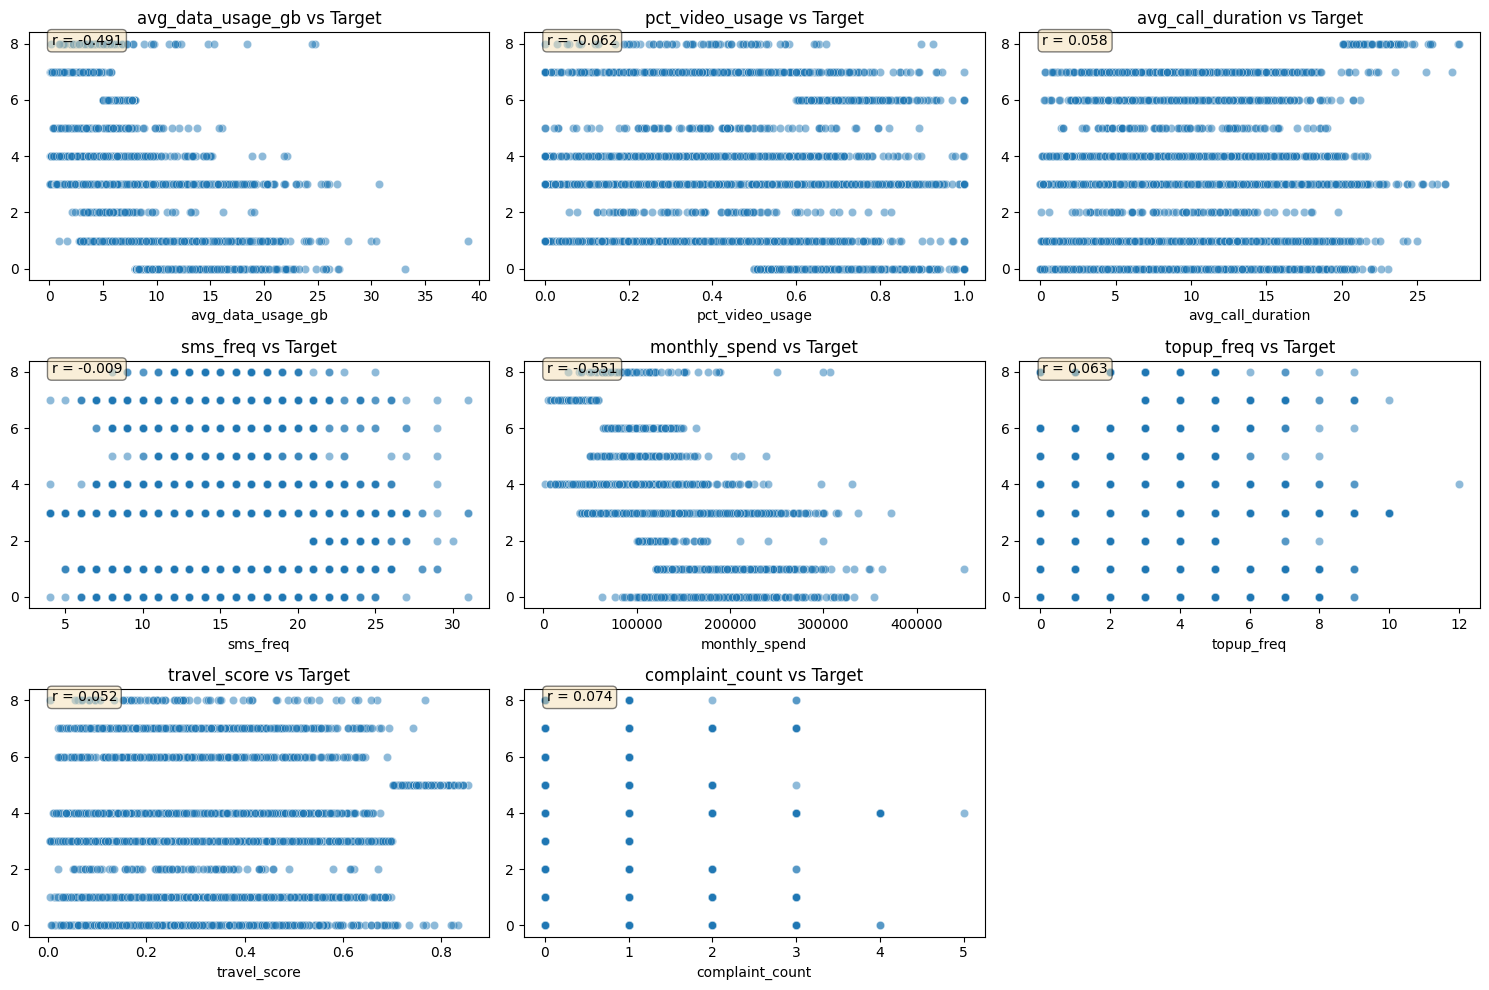

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.scatterplot(x=df[col], y=y, alpha=0.5)
    plt.title(f"{col} vs Target")

    # Add correlation coefficient
    corr = np.corrcoef(df[col], y)[0, 1]
    plt.text(0.05, 0.95, f'r = {corr:.3f}', transform=plt.gca().transAxes,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.show()

In [ ]:
print("Plan Type Distribution:")
print(df["plan_type"].value_counts())
df["plan_type"] = df["plan_type"].map({"Prepaid": 0, "Postpaid": 1})

print("Device Brand Distribution:")
print(df["device_brand"].value_counts())
df = pd.get_dummies(df, columns=["device_brand"], drop_first=True)

Plan Type Distribution:
plan_type
Prepaid     6108
Postpaid    3892
Name: count, dtype: int64
Device Brand Distribution:
device_brand
Realme     1509
Xiaomi     1458
Samsung    1439
Huawei     1438
Vivo       1395
Apple      1386
Oppo       1375
Name: count, dtype: int64


In [ ]:
#scaling
scaler = RobustScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [ ]:
le_target = LabelEncoder()
y = le_target.fit_transform(df["target_offer"])

In [ ]:
#train test split
X = df.drop(columns=["target_offer"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
#K-fold for validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
temp_model = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=len(np.unique(y)),
    eval_metric="mlogloss",
    random_state=42
)
scores = cross_val_score(temp_model, X, y, cv=skf, scoring="accuracy")
print("Hasil tiap fold:", scores)
print(f"Rata-rata akurasi: {scores.mean():.4f} (± {scores.std():.4f})")

Hasil tiap fold: [0.996  0.995  0.9965 0.9935 0.993 ]
Rata-rata akurasi: 0.9948 (± 0.0014)


In [ ]:
#krn hasil k-fold sudah cukup bagus saya lanjut ke training

In [ ]:
#training
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=len(np.unique(y)),
    eval_metric="mlogloss",
    random_state=42
)
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=9, ...)

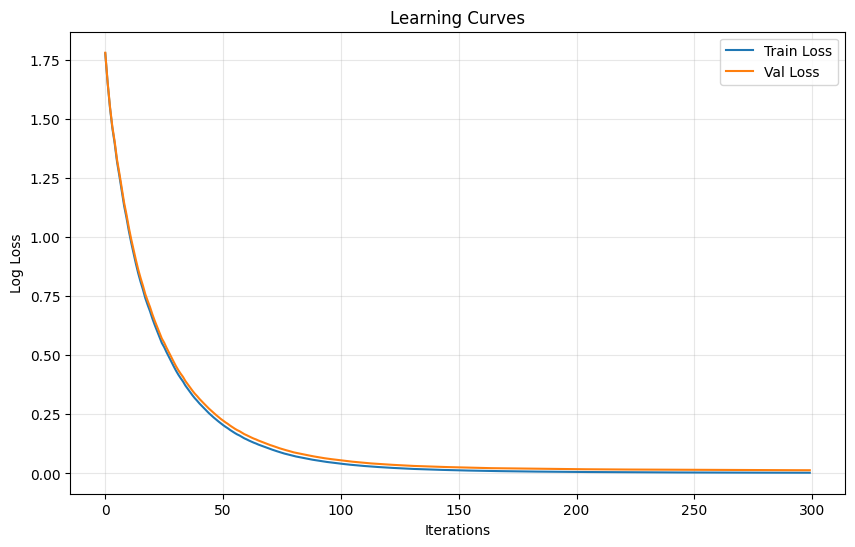

In [ ]:
#learning curve
results = model.evals_result()
plt.figure(figsize=(10, 6))
plt.plot(results["validation_0"]["mlogloss"], label="Train Loss")
plt.plot(results["validation_1"]["mlogloss"], label="Val Loss")
plt.xlabel("Iterations")
plt.ylabel("Log Loss")
plt.title("Learning Curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
#evaluasi
y_pred = model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       159
           1       1.00      1.00      1.00       300
           2       0.94      1.00      0.97        16
           3       1.00      1.00      1.00      1214
           4       1.00      0.99      1.00       152
           5       0.86      0.95      0.90        19
           6       1.00      1.00      1.00        52
           7       1.00      0.99      0.99        74
           8       1.00      0.93      0.96        14

    accuracy                           1.00      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       1.00      1.00      1.00      2000


Confusion Matrix:
[[ 159    0    0    0    0    0    0    0    0]
 [   1  299    0    0    0    0    0    0    0]
 [   0    0   16    0    0    0    0    0    0]
 [   1    0    0 1211    0    2    0    0    0]
 [   0    0    0    1  151    0    0    0    0]
 [   0    0  

                 feature  importance
8        complaint_count    0.241347
9    device_brand_Huawei    0.146888
11   device_brand_Realme    0.126456
5          monthly_spend    0.083621
2        pct_video_usage    0.056891
1      avg_data_usage_gb    0.054121
12  device_brand_Samsung    0.049191
10     device_brand_Oppo    0.045057
0              plan_type    0.044911
14   device_brand_Xiaomi    0.042889


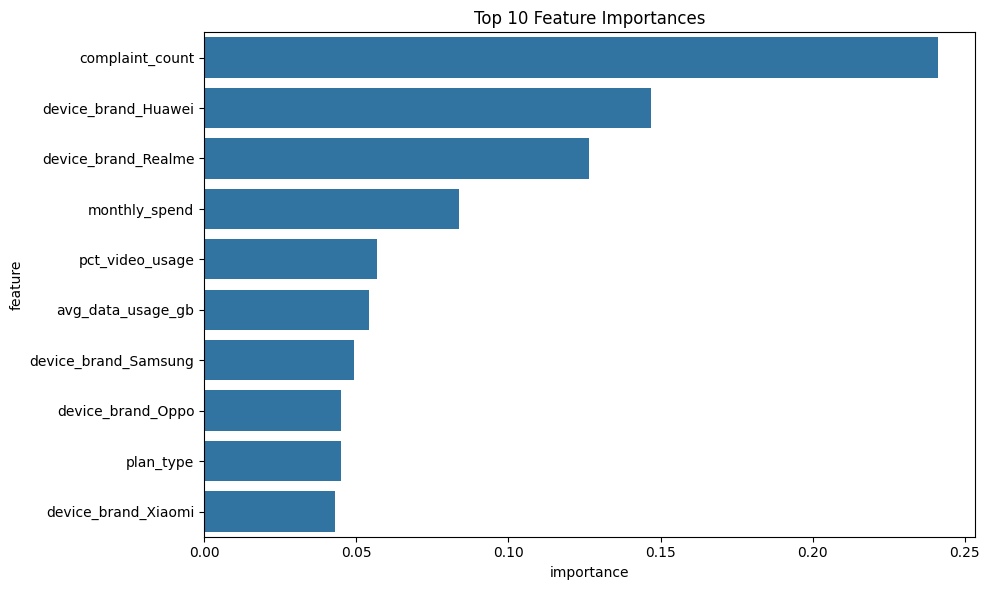

In [ ]:
#kolom yg paling berpengaruh
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
plt.title('Top 10 Feature Importances')
plt.tight_layout()
plt.show()

In [ ]:
import joblib

# Save model
joblib.dump(model, "xgb_model.pkl")

# Save label encoder (untuk target_offer)
joblib.dump(le_target, "label_encoder.pkl")

# Save columns for input order
joblib.dump(list(X_train.columns), "model_features.pkl")

['model_features.pkl']